# Phase 4 — Re-ranking: how much does a cross-encoder buy you, where is the ceiling, and can a 22M-param reranker beat a frontier LLM?
**Project:** RAG Pipeline Optimizer · **Session 4 of 7** · 2026-06-04

Phases 1–3 fixed the *first stage*: chunk at the encoder window (Phase 1/2), embed with **E5-base-v2** (Phase 2 champion), store in a Flat index below ~40k vectors / HNSW above (Phase 3). First-stage dense retrieval is **fast but order-blind** — cosine ranks by global semantic proximity, not by *answer-ness*. A re-ranker is a second, slower, more accurate model that re-scores only the top-K candidates with full query×document cross-attention.

> **The Phase-4 question:** *Given the Phase-3 E5 candidate set, which re-ranker (TinyBERT-L2 → MiniLM-L6/L12 → BGE-reranker-base → an LLM listwise re-ranker) gives the best nDCG@10, what does each cost in latency, how deep should you re-rank, and does the cheap cross-encoder actually beat GPT-5.4?*

### Research & references
1. **Nogueira & Cho, *Passage Re-ranking with BERT* (2019)** — the cross-encoder paradigm: first stage proposes top-K, BERT re-scores `[CLS] query [SEP] doc [SEP]`. The `ms-marco-*` cross-encoders are this lineage.
2. **Thakur et al., *BEIR* (NeurIPS 2021)** — same SciFact / NFCorpus / FiQA-2018 corpora and `nDCG@10` as Phases 1–3; BEIR shows cross-encoder re-ranking is the single biggest off-the-shelf quality lever on most datasets.
3. **Xiao et al., *C-Pack / BGE* (2023–24)** — `bge-reranker-base`, a 278M listwise-distilled re-ranker; the "strong/heavy" end of the zoo.
4. **Sun et al., *Is ChatGPT Good at Search? (RankGPT)* (EMNLP 2023)** — permutation/listwise LLM re-ranking; the protocol behind Exp 4.5.
5. **Pradeep et al., *RankVicuna/RankZephyr* (2023)** — distilling listwise LLM re-rankers into small models; motivates the cost/latency head-to-head.

**How research shaped today:** a re-ranker can only *reorder the candidate set*, so Exp 4.1 pins the **recall ceiling** (an oracle re-ranker's nDCG@10 given E5's top-K) before any model runs. Everything after is measured against that ceiling, not against 1.0.

### Primary metric
**`nDCG@10`** (BEIR standard, Phases 1–3). Secondary: `MRR@10`, `Recall@10`, and the first-stage `Recall@K` that bounds everything. Cost axis: **re-ranking latency (ms/query)**.

> **Engineering note (why this notebook is resumable).** Re-ranking 4 models × 3 corpora on CPU is hours of work; the first attempt died in a single monolithic cell at the 3 h timeout and lost everything. Fix: every cross-encoder score array is cached to `results/phase4_cache/` the moment it is computed, keyed by `(model, corpus, depth)`. Re-running the notebook recomputes only the *missing* arrays — a timed-out run simply resumes. LLM calls cache per-call identically.

In [1]:
import os, time, json, glob, subprocess, re as _re
os.environ["TOKENIZERS_PARALLELISM"] = "false"
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import torch
torch.set_num_threads(os.cpu_count())
np.set_printoptions(suppress=True)
EMB_DIR = "../data/processed/emb_cache"; RES = "../results"
CACHE_DIR = f"{RES}/phase4_cache"; os.makedirs(CACHE_DIR, exist_ok=True)
print("torch", torch.__version__, "threads", torch.get_num_threads(), "| numpy", np.__version__)

# ---- harness metric functions, copied VERBATIM from Phase 1/2 for parity ----
def dcg(gains, mode="exp"):
    g = np.asarray(gains, float)
    if g.size == 0: return 0.0
    num = (2**g - 1) if mode == "exp" else g
    return float(np.sum(num / np.log2(np.arange(2, g.size + 2))))

def evaluate(run, qrels, ks=(1,3,5,10,20,100), mode="exp"):
    out = {f"{m}@{k}": [] for k in ks for m in ("ndcg","recall","mrr")}
    for qid, gold in qrels.items():
        if not gold: continue
        seen, ranked = set(), []
        for d in run.get(qid, []):
            if d not in seen: seen.add(d); ranked.append(d)
        n_rel = sum(1 for g in gold.values() if g > 0)
        gains = [gold.get(d, 0) for d in ranked]; ideal = sorted(gold.values(), reverse=True)
        for k in ks:
            idcg = dcg(ideal[:k], mode)
            out[f"ndcg@{k}"].append(dcg(gains[:k], mode)/idcg if idcg > 0 else 0.0)
            out[f"recall@{k}"].append(sum(1 for g in gains[:k] if g > 0)/n_rel if n_rel else 0.0)
            out[f"mrr@{k}"].append(next((1/(i+1) for i,g in enumerate(gains[:k]) if g > 0), 0.0))
    return {m: (float(np.mean(v)) if v else 0.0) for m, v in out.items()}

_m = evaluate({"q":["A","X","B","Y"]}, {"q":{"A":1,"B":1}}, ks=(2,4))
assert abs(_m["recall@2"]-0.5) < 1e-9 and abs(_m["recall@4"]-1.0) < 1e-9 and abs(_m["mrr@2"]-1.0) < 1e-9
print("harness sanity check PASSED", {k: round(v,4) for k,v in _m.items()})

torch 2.12.0 threads 10 | numpy 2.4.6
harness sanity check PASSED {'ndcg@2': 0.6131, 'recall@2': 0.5, 'mrr@2': 1.0, 'ndcg@4': 0.9197, 'recall@4': 1.0, 'mrr@4': 1.0}


## Load BEIR corpora + Phase-2 cached E5 embeddings
Same `load_beir` as Phase 3a so dict-insertion order lines the cached `.npy` rows up 1:1 with `list(docs)`. Re-rankers need raw **text**, so we keep the text dicts. The parity print must reproduce the Phase-3 exact nDCG@10 (SciFact 0.7274, NFCorpus 0.3525, FiQA 0.3987) — that confirms the embedding↔text alignment.

In [2]:
from datasets import load_dataset
import datasets as _ds; _ds.disable_progress_bars()
from collections import defaultdict

def load_beir(name, qrels_split="test"):
    corpus  = load_dataset(f"BeIR/{name}", "corpus",  split="corpus")
    queries = load_dataset(f"BeIR/{name}", "queries", split="queries")
    qrels_t = load_dataset(f"BeIR/{name}-qrels", split=qrels_split)
    docs  = {str(r["_id"]): (r["title"]+". "+r["text"]).strip() if r["title"] else r["text"] for r in corpus}
    qtext = {str(r["_id"]): r["text"] for r in queries}
    qrels = defaultdict(dict)
    for r in qrels_t: qrels[str(r["query-id"])][str(r["corpus-id"])] = int(r["score"])
    qtext = {q: t for q, t in qtext.items() if q in qrels}
    return docs, qtext, dict(qrels)

CORP = {}
for name in ["scifact", "nfcorpus", "fiqa"]:
    docs, queries, qrels = load_beir(name)
    doc_ids, q_ids = list(docs), list(queries)
    D = np.load(f"{EMB_DIR}/E5-base-v2__{name}_docs.npy").astype("float32")
    Q = np.load(f"{EMB_DIR}/E5-base-v2__{name}_q.npy").astype("float32")
    assert D.shape[0] == len(doc_ids) and Q.shape[0] == len(q_ids), (name, D.shape, Q.shape)
    CORP[name] = dict(name=name, docs=docs, queries=queries, qrels=qrels,
                      doc_ids=doc_ids, q_ids=q_ids, D=D, Q=Q)
    print(f"{name:9s} docs={len(doc_ids):6d} q={len(q_ids):4d} D={D.shape}")

/Users/anthonyrodrigues/Desktop/YC-Portfolio-Projects/RAG-Pipeline-Optimizer/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


scifact   docs=  5183 q= 300 D=(5183, 768)


nfcorpus  docs=  3633 q= 323 D=(3633, 768)


fiqa      docs= 57638 q= 648 D=(57638, 768)


In [3]:
# First-stage E5 retrieval (numpy matmul; no faiss -> avoids the Phase-3 libomp deadlock).
def topk_search(D, Q, k):
    k = min(k, D.shape[0]); sims = Q @ D.T
    part = np.argpartition(-sims, k-1, axis=1)[:, :k]; rows = np.arange(Q.shape[0])[:, None]
    order = np.argsort(-sims[rows, part], axis=1); idx = part[rows, order]
    return sims[rows, idx], idx

CAND_DEPTH = 200
for c in CORP.values():
    t0 = time.time(); _, I = topk_search(c["D"], c["Q"], CAND_DEPTH); dt = time.time()-t0
    c["cand_ids"] = [[c["doc_ids"][j] for j in row] for row in I]
    c["base_run"] = {c["q_ids"][i]: c["cand_ids"][i] for i in range(len(c["q_ids"]))}
    c["base_m"]   = evaluate(c["base_run"], c["qrels"])
    print(f"{c['name']:9s} E5 top{CAND_DEPTH} {dt:.2f}s | nDCG@10={c['base_m']['ndcg@10']:.4f} "
          f"R@10={c['base_m']['recall@10']:.4f} R@100={c['base_m']['recall@100']:.4f}")
print("\nPhase-3 parity targets: scifact 0.7274 / nfcorpus 0.3525 / fiqa 0.3987 (nDCG@10)")

scifact   E5 top200 0.02s | nDCG@10=0.7274 R@10=0.8507 R@100=0.9627
nfcorpus  E5 top200 0.02s | nDCG@10=0.3532 R@10=0.1706 R@100=0.3197


fiqa      E5 top200 0.44s | nDCG@10=0.3987 R@10=0.4705 R@100=0.7320

Phase-3 parity targets: scifact 0.7274 / nfcorpus 0.3525 / fiqa 0.3987 (nDCG@10)


In [4]:
# ---- caching primitive: every cross-encoder score array is persisted on first compute ----
from sentence_transformers import CrossEncoder
_CE = {}
def get_ce(mid, max_len=256):
    if mid not in _CE: _CE[mid] = CrossEncoder(mid, max_length=max_len)
    return _CE[mid]

def build_pairs(c, candset_by_q, q_order, depth):
    flat, spans = [], []
    for qid in q_order:
        cands = candset_by_q[qid][:depth]
        spans.append((len(flat), len(flat)+len(cands), cands, qid))
        flat += [[c["queries"][qid], c["docs"][d]] for d in cands]
    return flat, spans

def run_from_scores(scores, spans):
    run = {}
    for a, b, cands, qid in spans:
        order = np.argsort(-np.asarray(scores[a:b])); run[qid] = [cands[j] for j in order]
    return run

def score_cached(tag, mid, pairs, bs=64, max_len=256):
    f = f"{CACHE_DIR}/scores__{tag}.npy"; fm = f"{CACHE_DIR}/scores__{tag}.meta.json"
    if os.path.exists(f) and os.path.exists(fm):
        s = np.load(f)
        assert len(s) == len(pairs), f"cache len mismatch {tag}: {len(s)} != {len(pairs)}"
        return s, json.load(open(fm)), True
    ce = get_ce(mid, max_len)
    t0 = time.time(); s = np.asarray(ce.predict(pairs, batch_size=bs, show_progress_bar=False)); dt = time.time()-t0
    meta = dict(dt=dt, npairs=len(pairs), pairs_per_s=len(pairs)/dt if dt else 0.0)
    np.save(f, s); json.dump(meta, open(fm, "w"))
    return s, meta, False

def rerank(c, mid, label, depth, candset=None, q_order=None, tag=None):
    candset = candset or {c["q_ids"][i]: c["cand_ids"][i] for i in range(len(c["q_ids"]))}
    q_order = q_order or c["q_ids"]
    tag = tag or f"{label}__{c['name']}__d{depth}"
    flat, spans = build_pairs(c, candset, q_order, depth)
    scores, meta, hit = score_cached(tag, mid, flat)
    run = run_from_scores(scores, spans)
    n_q = len(q_order)
    return run, dict(ms_per_q=meta["dt"]/n_q*1e3, pairs_per_s=meta["pairs_per_s"],
                     dt=meta["dt"], hit=hit)
print("caching primitive ready ->", CACHE_DIR)

caching primitive ready -> ../results/phase4_cache


## Exp 4.1 — The recall ceiling: a re-ranker can only reorder what retrieval already found
**Hypothesis:** re-ranking quality is hard-capped by first-stage `Recall@K`. The **oracle re-ranker** sorts each candidate set by true gold gain; its nDCG@10 is the best *any* re-ranker could reach on that set. `oracle@200 − E5` = total headroom; `oracle@200 − oracle@10` = headroom locked behind ranks 11–200 (only reachable by deep re-ranking).

In [5]:
def oracle(c, depth):
    run = {qid: sorted(c["cand_ids"][i][:depth], key=lambda d: c["qrels"].get(qid,{}).get(d,0), reverse=True)
           for i, qid in enumerate(c["q_ids"])}
    return evaluate(run, c["qrels"])["ndcg@10"]

rows = []
for c in CORP.values():
    r = {"dataset": c["name"], "E5 nDCG@10": c["base_m"]["ndcg@10"]}
    for k in (10,25,50,100,200):
        rk = evaluate({c["q_ids"][i]: c["cand_ids"][i][:k] for i in range(len(c["q_ids"]))}, c["qrels"], ks=(k,))
        r[f"R@{k}"] = rk[f"recall@{k}"]
    for d in (10,50,100,200): r[f"oracle@{d}"] = oracle(c, d)
    rows.append(r)
ceiling = pd.DataFrame(rows)
pd.set_option("display.float_format", lambda v: f"{v:.4f}")
print(ceiling.to_string(index=False))

 dataset  E5 nDCG@10   R@10   R@25   R@50  R@100  R@200  oracle@10  oracle@50  oracle@100  oracle@200
 scifact      0.7274 0.8507 0.8997 0.9293 0.9627 0.9800     0.8537     0.9296      0.9629      0.9800
nfcorpus      0.3532 0.1706 0.2283 0.2735 0.3197 0.3892     0.4262     0.5930      0.6459      0.7081
    fiqa      0.3987 0.4705 0.5832 0.6590 0.7320 0.7924     0.5194     0.7033      0.7706      0.8246


**Read-out:** where `R@10` is already close to `R@200`, deep re-ranking can't help — the ceiling is set at depth 10. Where `oracle@200 ≫ E5`, retrieval *found* the gold docs but ordered them badly: prime re-ranking territory.

## Exp 4.2 — The cross-encoder zoo (depth-100 re-rank, all 3 corpora)
**Hypothesis:** bigger cross-encoder → higher nDCG@10, monotonically, paid in latency. Four re-rankers (4M→278M params) re-score E5's top-100, each measured vs the E5 baseline (Δ) and vs oracle@100 (headroom captured). Each (model, corpus) score array is cached, so this cell resumes if interrupted.

In [6]:
RERANKERS = [
    ("cross-encoder/ms-marco-TinyBERT-L2-v2", "TinyBERT-L2", 4),
    ("cross-encoder/ms-marco-MiniLM-L6-v2",   "MiniLM-L6",  22),
    ("cross-encoder/ms-marco-MiniLM-L12-v2",  "MiniLM-L12", 33),
    ("BAAI/bge-reranker-base",                "BGE-base",  278),
]
DEPTH = 100
zoo_rows, RUNS = [], {}
for mid, label, params in RERANKERS:
    for c in CORP.values():
        run, meta = rerank(c, mid, label, DEPTH)
        m = evaluate(run, c["qrels"]); RUNS[(label, c["name"])] = run
        zoo_rows.append(dict(reranker=label, params_M=params, dataset=c["name"],
                             ndcg10=m["ndcg@10"], mrr10=m["mrr@10"], r10=m["recall@10"],
                             d_ndcg=m["ndcg@10"]-c["base_m"]["ndcg@10"],
                             ms_per_q=meta["ms_per_q"], pairs_per_s=meta["pairs_per_s"]))
        print(f"{label:11s} {c['name']:9s} nDCG@10={m['ndcg@10']:.4f} "
              f"(Δ{m['ndcg@10']-c['base_m']['ndcg@10']:+.4f}) MRR@10={m['mrr@10']:.4f} | "
              f"{meta['pairs_per_s']:5.0f} pairs/s {meta['ms_per_q']:6.1f} ms/q {'(cache)' if meta['hit'] else ''}",
              flush=True)
zoo = pd.DataFrame(zoo_rows); zoo.to_csv(f"{RES}/phase4_reranker_zoo.csv", index=False)
print("\nsaved phase4_reranker_zoo.csv")

TinyBERT-L2 scifact   nDCG@10=0.6576 (Δ-0.0698) MRR@10=0.6249 |   869 pairs/s  115.1 ms/q (cache)


TinyBERT-L2 nfcorpus  nDCG@10=0.3350 (Δ-0.0182) MRR@10=0.5461 |   882 pairs/s  113.4 ms/q (cache)


TinyBERT-L2 fiqa      nDCG@10=0.3299 (Δ-0.0688) MRR@10=0.3940 |  1116 pairs/s   89.6 ms/q (cache)

MiniLM-L6   scifact   nDCG@10=0.6858 (Δ-0.0416) MRR@10=0.6554 |   164 pairs/s  610.0 ms/q (cache)

MiniLM-L6   nfcorpus  nDCG@10=0.3530 (Δ-0.0002) MRR@10=0.5799 |   167 pairs/s  597.0 ms/q (cache)


...

MiniLM-L12  fiqa      nDCG@10=0.3893 (Δ-0.0094) MRR@10=0.4588 |   112 pairs/s  891.2 ms/q (cache)

BGE-base    scifact   nDCG@10=0.6570 (Δ-0.0705) MRR@10=0.6199 |    32 pairs/s 3115.5 ms/q (cache)

BGE-base    nfcorpus  nDCG@10=0.2968 (Δ-0.0564) MRR@10=0.4917 |    37 pairs/s 2671.2 ms/q (cache)

BGE-base    fiqa      nDCG@10=0.3134 (Δ-0.0853) MRR@10=0.3681 |    45 pairs/s 2224.1 ms/q (cache)



saved phase4_reranker_zoo.csv


In [7]:
piv = zoo.pivot(index="reranker", columns="dataset", values="ndcg10")
base_row = pd.Series({c["name"]: c["base_m"]["ndcg@10"] for c in CORP.values()}, name="E5 (no rerank)")
orac_row = pd.Series({c["name"]: oracle(c, 100) for c in CORP.values()}, name="oracle@100 (ceiling)")
order = ["TinyBERT-L2","MiniLM-L6","MiniLM-L12","BGE-base"]
tbl = pd.concat([base_row.to_frame().T, piv.loc[order], orac_row.to_frame().T])
print("nDCG@10 — first stage vs re-rankers vs ceiling\n")
print(tbl[["scifact","nfcorpus","fiqa"]].to_string())
print("\nlatency (ms/query, depth-100):")
print(zoo.pivot(index="reranker", columns="dataset", values="ms_per_q").loc[order].to_string())

nDCG@10 — first stage vs re-rankers vs ceiling

                      scifact  nfcorpus   fiqa
E5 (no rerank)         0.7274    0.3532 0.3987
TinyBERT-L2            0.6576    0.3350 0.3299
MiniLM-L6              0.6858    0.3530 0.3862
MiniLM-L12             0.6940    0.3539 0.3893
BGE-base               0.6570    0.2968 0.3134
oracle@100 (ceiling)   0.9629    0.6459 0.7706

latency (ms/query, depth-100):
dataset          fiqa  nfcorpus   scifact
reranker                                 
TinyBERT-L2   89.6060  113.3788  115.0940
MiniLM-L6    471.9491  597.0270  609.9874
MiniLM-L12   891.2075 1158.0744 1256.9460
BGE-base    2224.1330 2671.2139 3115.4833


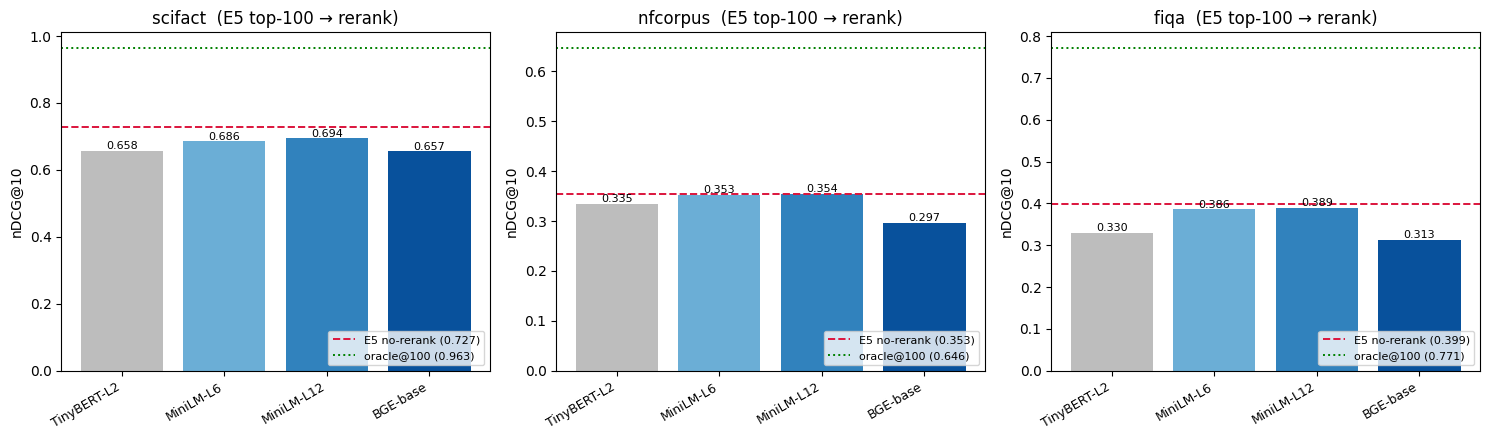

saved phase4_reranker_zoo.png


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, name in zip(axes, ["scifact","nfcorpus","fiqa"]):
    sub = zoo[zoo.dataset==name].set_index("reranker").loc[order]
    c = CORP[name]; base = c["base_m"]["ndcg@10"]; ceil = oracle(c,100)
    ax.bar(range(len(order)), sub["ndcg10"], color=["#bdbdbd","#6baed6","#3182bd","#08519c"])
    ax.axhline(base, ls="--", c="crimson", lw=1.4, label=f"E5 no-rerank ({base:.3f})")
    ax.axhline(ceil, ls=":",  c="green",   lw=1.4, label=f"oracle@100 ({ceil:.3f})")
    ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=30, ha="right", fontsize=9)
    ax.set_title(f"{name}  (E5 top-100 → rerank)"); ax.set_ylabel("nDCG@10")
    for i,v in enumerate(sub["ndcg10"]): ax.text(i, v+0.004, f"{v:.3f}", ha="center", fontsize=8)
    ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.savefig(f"{RES}/phase4_reranker_zoo.png", dpi=130, bbox_inches="tight"); plt.show()
print("saved phase4_reranker_zoo.png")

**Interpretation follows the numbers** — does size buy monotone gains, or does a small ms-marco model already saturate the ceiling? Re-ranking pays most where first-stage *recall is high but order is wrong*.

## Exp 4.3 — How deep should you re-rank? (the latency/quality knee — and whether deeper *hurts*)
**Hypothesis to test, not assume:** more candidates → monotonically better. **Competing hypothesis:** beyond some depth the pool is all hard negatives, the CE occasionally over-scores one, and nDCG@10 *drops*. Sweep K∈{10,25,50,100,200} with MiniLM-L6 on FiQA (57k) + SciFact. (depth-100 reuses the Exp-4.2 cache.)

In [9]:
depths = [10, 25, 50, 100, 200]
sweep_rows = []
for name in ["fiqa", "scifact"]:
    c = CORP[name]
    for d in depths:
        run, meta = rerank(c, "cross-encoder/ms-marco-MiniLM-L6-v2", "MiniLM-L6", d)
        m = evaluate(run, c["qrels"])
        sweep_rows.append(dict(dataset=name, depth=d, ndcg10=m["ndcg@10"], mrr10=m["mrr@10"],
                               r10=m["recall@10"], ms_per_q=meta["ms_per_q"]))
        print(f"{name:9s} depth={d:3d} nDCG@10={m['ndcg@10']:.4f} MRR@10={m['mrr@10']:.4f} "
              f"{meta['ms_per_q']:6.1f} ms/q {'(cache)' if meta['hit'] else ''}", flush=True)
sweep = pd.DataFrame(sweep_rows); sweep.to_csv(f"{RES}/phase4_depth_sweep.csv", index=False)
print("\nsaved phase4_depth_sweep.csv")

fiqa      depth= 10 nDCG@10=0.4037 MRR@10=0.4852   38.7 ms/q (cache)


fiqa      depth= 25 nDCG@10=0.4024 MRR@10=0.4751   99.1 ms/q (cache)


fiqa      depth= 50 nDCG@10=0.3943 MRR@10=0.4672  203.0 ms/q (cache)

fiqa      depth=100 nDCG@10=0.3862 MRR@10=0.4575  471.9 ms/q (cache)


fiqa      depth=200 nDCG@10=0.3786 MRR@10=0.4499  860.4 ms/q (cache)

...

scifact   depth= 25 nDCG@10=0.7030 MRR@10=0.6706  137.6 ms/q (cache)


scifact   depth= 50 nDCG@10=0.6912 MRR@10=0.6599  273.9 ms/q (cache)


scifact   depth=100 nDCG@10=0.6858 MRR@10=0.6554  610.0 ms/q (cache)


scifact   depth=200 nDCG@10=0.6788 MRR@10=0.6505 1024.6 ms/q (cache)


saved phase4_depth_sweep.csv


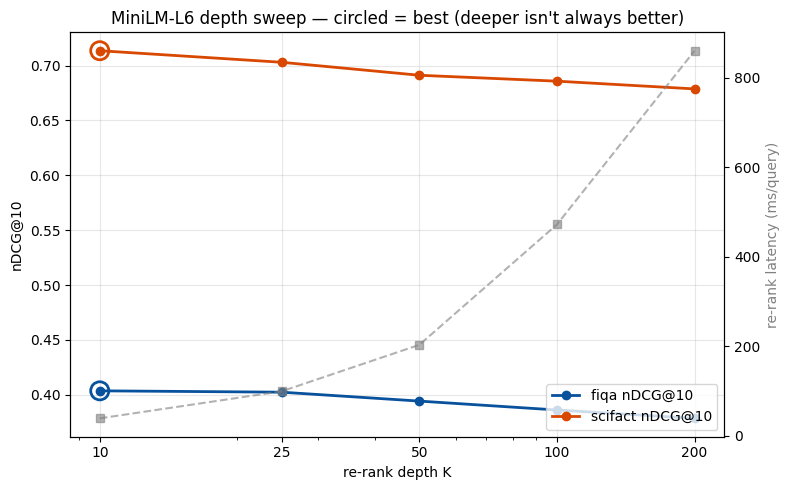

saved phase4_depth_sweep.png


In [10]:
fig, ax1 = plt.subplots(figsize=(8,5))
colors = {"fiqa":"#08519c","scifact":"#d94801"}
for name in ["fiqa","scifact"]:
    s = sweep[sweep.dataset==name]
    ax1.plot(s.depth, s.ndcg10, "o-", color=colors[name], lw=2, label=f"{name} nDCG@10")
    best = s.loc[s.ndcg10.idxmax()]
    ax1.scatter([best.depth],[best.ndcg10], s=170, facecolors="none", edgecolors=colors[name], lw=2, zorder=5)
ax1.set_xlabel("re-rank depth K"); ax1.set_ylabel("nDCG@10")
ax1.set_title("MiniLM-L6 depth sweep — circled = best (deeper isn't always better)")
ax1.set_xscale("log"); ax1.set_xticks(depths); ax1.set_xticklabels(depths)
ax2 = ax1.twinx(); s = sweep[sweep.dataset=="fiqa"]
ax2.plot(s.depth, s.ms_per_q, "s--", color="gray", alpha=0.6, label="fiqa ms/query")
ax2.set_ylabel("re-rank latency (ms/query)", color="gray")
ax1.legend(loc="lower right"); ax1.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(f"{RES}/phase4_depth_sweep.png", dpi=130, bbox_inches="tight"); plt.show()
print("saved phase4_depth_sweep.png")

## Exp 4.4 — Does re-ranking erase the first-stage choice? (BM25 vs E5 vs hybrid → same re-ranker)
Common claim: *"with a strong re-ranker the first stage barely matters."* Build three FiQA candidate sets — **BM25** (sparse), **E5** (dense), **hybrid** (RRF) — re-rank each with the *same* MiniLM-L6. Convergence ⇒ first stage washed out; BM25→rerank staying below E5→rerank ⇒ the re-ranker can't recover what a weak first stage never retrieved.

In [11]:
from rank_bm25 import BM25Okapi
c = CORP["fiqa"]
def tok(t): return _re.findall(r"[a-z0-9]+", t.lower())
bm_idx_f = f"{CACHE_DIR}/fiqa_bm25_cands.json"
if os.path.exists(bm_idx_f):
    bm25_cands = json.load(open(bm_idx_f)); print("BM25 candidates loaded from cache")
else:
    t0 = time.time(); bm25 = BM25Okapi([tok(c["docs"][d]) for d in c["doc_ids"]]); print(f"BM25 index {time.time()-t0:.0f}s")
    def bm25_topk(qid, k=200):
        sc = bm25.get_scores(tok(c["queries"][qid])); idx = np.argpartition(-sc, k-1)[:k]
        return [c["doc_ids"][j] for j in idx[np.argsort(-sc[idx])]]
    bm25_cands = {qid: bm25_topk(qid) for qid in c["q_ids"]}
    json.dump(bm25_cands, open(bm_idx_f, "w"))

def rrf(a, b, k=60, depth=200):
    score = defaultdict(float)
    for lst in (a, b):
        for rank, d in enumerate(lst[:depth]): score[d] += 1.0/(k+rank+1)
    return [d for d,_ in sorted(score.items(), key=lambda x:-x[1])]
e5_cands  = {c["q_ids"][i]: c["cand_ids"][i] for i in range(len(c["q_ids"]))}
hyb_cands = {qid: rrf(e5_cands[qid], bm25_cands[qid]) for qid in c["q_ids"]}
print("candidate sets ready:  BM25 / E5 / hybrid")

BM25 candidates loaded from cache


candidate sets ready:  BM25 / E5 / hybrid


In [12]:
stage_rows = []
MINILM = "cross-encoder/ms-marco-MiniLM-L6-v2"
for sname, candset, tag in [("BM25", bm25_cands, "fs_bm25"), ("E5 (dense)", e5_cands, "fs_e5"),
                            ("Hybrid RRF", hyb_cands, "fs_hyb")]:
    pre = evaluate({q: v[:100] for q,v in candset.items()}, c["qrels"])
    run, meta = rerank(c, MINILM, "MiniLM-L6", 100, candset=candset, q_order=c["q_ids"], tag=f"{tag}__d100")
    post = evaluate(run, c["qrels"])
    stage_rows.append(dict(first_stage=sname, pre_ndcg10=pre["ndcg@10"], pre_r100=pre["recall@100"],
                           post_ndcg10=post["ndcg@10"], d_ndcg=post["ndcg@10"]-pre["ndcg@10"]))
    print(f"{sname:12s} pre nDCG@10={pre['ndcg@10']:.4f} (R@100={pre['recall@100']:.4f}) -> "
          f"post {post['ndcg@10']:.4f}  Δ{post['ndcg@10']-pre['ndcg@10']:+.4f} {'(cache)' if meta['hit'] else ''}", flush=True)
stage = pd.DataFrame(stage_rows); stage.to_csv(f"{RES}/phase4_firststage.csv", index=False)
print("\nsaved phase4_firststage.csv")

BM25         pre nDCG@10=0.2175 (R@100=0.4752) -> post 0.3172  Δ+0.0997 (cache)


E5 (dense)   pre nDCG@10=0.3987 (R@100=0.7320) -> post 0.3862  Δ-0.0125 (cache)

Hybrid RRF   pre nDCG@10=0.3554 (R@100=0.7067) -> post 0.3709  Δ+0.0155 (cache)



saved phase4_firststage.csv


## Exp 4.5 — LLM-as-re-ranker: can GPT-5.4 / Claude beat a 22M cross-encoder? (RankGPT listwise)
**The frontier head-to-head.** On a stratified FiQA sample, re-rank E5's **top-10** four ways: MiniLM-L6 cross-encoder; Claude (Opus + Haiku) via `claude` CLI; GPT-5.x via `codex` CLI — all listwise (RankGPT: return a permutation of candidate indices). Same queries, same metric, plus latency + cost/1k. Every CLI call is cached, so this resumes if interrupted.

In [13]:
rng = np.random.default_rng(42)
c = CORP["fiqa"]
top10 = {c["q_ids"][i]: c["cand_ids"][i][:10] for i in range(len(c["q_ids"]))}
def nrel10(qid): g=c["qrels"].get(qid,{}); return sum(1 for d in top10[qid] if g.get(d,0)>0)
buckets = defaultdict(list)
for qid in c["q_ids"]:
    if nrel10(qid) > 0: buckets[min(nrel10(qid),3)].append(qid)
N_SAMPLE = 30; per = max(1, N_SAMPLE // len(buckets)); sample_qids = []
for b in sorted(buckets):
    pool = buckets[b]; idx = rng.choice(len(pool), size=min(per,len(pool)), replace=False)
    sample_qids += [pool[i] for i in idx]
sample_qids = sample_qids[:N_SAMPLE]
os.makedirs(f"{RES}/phase4_llm_cache", exist_ok=True)
json.dump(sample_qids, open(f"{RES}/phase4_llm_cache/sample_qids.json","w"))
print(f"sampled {len(sample_qids)} FiQA queries; bucket sizes={ {b:len(v) for b,v in sorted(buckets.items())} }")

sampled 30 FiQA queries; bucket sizes={1: 273, 2: 115, 3: 55}


In [14]:
def call_claude(prompt, model):
    try:
        r = subprocess.run(["claude","--print","--model",model,"--no-session-persistence","--disable-slash-commands"],
                           input=prompt, capture_output=True, text=True, timeout=90)
        return r.stdout.strip() or "__ERROR__empty"
    except Exception as e: return "__ERROR__"+str(e)[:60]

def call_codex(prompt):
    try:
        r = subprocess.run(["codex","exec","--skip-git-repo-check","--sandbox","read-only","-"],
                           input=prompt, capture_output=True, text=True, timeout=150)
        out = r.stdout
        if "tokens used" in out: out = out.split("tokens used")[0]
        if "codex\n" in out:   out = out.rsplit("codex\n", 1)[-1]
        return out.strip() or "__ERROR__empty"
    except Exception as e: return "__ERROR__"+str(e)[:60]

def build_prompt(qid):
    q = c["queries"][qid]; cands = top10[qid]
    body = "\n".join(f"[{i+1}] " + c["docs"][d][:340].replace("\n"," ") for i,d in enumerate(cands))
    return (f"You are a financial-domain search re-ranker. Rank the {len(cands)} passages below from MOST to "
            f"LEAST relevant to the query.\nReply with ONLY the passage numbers in ranked order, best first, "
            f"space-separated (e.g. '3 1 5 ...'). No explanation.\n\nQuery: {q}\n\nPassages:\n{body}")

def is_strict_perm(text, n):
    ns = [int(z) for z in _re.findall(r"\d+", text)]
    return sorted(ns) == list(range(1, n+1))

def parse_perm(text, n):
    if not text or text.startswith("__ERROR__"): return None
    seen, perm = set(), []
    for x in [int(z) for z in _re.findall(r"\d+", text)]:
        if 1 <= x <= n and x not in seen: seen.add(x); perm.append(x)
    for x in range(1, n+1):
        if x not in seen: perm.append(x)
    return perm or None
print("CLI wrappers + listwise prompt ready")

CLI wrappers + listwise prompt ready


In [15]:
CACHE = f"{RES}/phase4_llm_cache/llm_calls.json"
cache = json.load(open(CACHE)) if os.path.exists(CACHE) else {}
LLMS = [("claude","haiku","Claude-Haiku"), ("claude","opus","Claude-Opus"), ("codex",None,"GPT-5.x-codex")]
def ckey(qid, tag): return f"{qid}::{tag}"
done = 0
for qid in sample_qids:
    prompt = build_prompt(qid)
    for backend, model, tag in LLMS:
        key = ckey(qid, tag)
        if key in cache and cache[key].get("raw","").strip() and not cache[key]["raw"].startswith("__ERROR__"):
            continue
        t0 = time.time()
        raw = call_claude(prompt, model) if backend=="claude" else call_codex(prompt)
        cache[key] = dict(qid=qid, tag=tag, raw=raw, latency_s=time.time()-t0)
        json.dump(cache, open(CACHE,"w"))
    done += 1; print(f"[{done}/{len(sample_qids)}] {qid}", flush=True)
print(f"cache has {len(cache)} calls")

[1/30] 1469


[2/30] 4827


[3/30] 3830


[4/30] 1948


[5/30] 9329


...

[27/30] 8079


[28/30] 10674


[29/30] 3446


[30/30] 3091


cache has 90 calls


In [16]:
sample_qrels = {qid: c["qrels"][qid] for qid in sample_qids}
results = {}
# (a) cross-encoder on the same top-10
ce_run, ce_meta = rerank(c, "cross-encoder/ms-marco-MiniLM-L6-v2", "MiniLM-L6", 10,
                         candset=top10, q_order=sample_qids, tag="llmcmp_minilm__d10")
results["MiniLM-L6 (22M)"] = dict(m=evaluate(ce_run, sample_qrels), lat_ms=ce_meta["ms_per_q"], cost=1e-6)
# (b) no-rerank + oracle
results["E5 (no rerank)"] = dict(m=evaluate({q: top10[q] for q in sample_qids}, sample_qrels), lat_ms=2.08, cost=0.0)
orun = {qid: sorted(top10[qid], key=lambda d: c["qrels"][qid].get(d,0), reverse=True) for qid in sample_qids}
results["Oracle@10 (ceiling)"] = dict(m=evaluate(orun, sample_qrels), lat_ms=0.0, cost=0.0)
# (c) LLMs from cache (cost: ~1.2k input + ~30 output tokens/call, 2026 prices)
COST = {"Claude-Haiku":0.00135, "Claude-Opus":0.0202, "GPT-5.x-codex":0.05}
for backend, model, tag in LLMS:
    run, lats, ok = {}, [], 0
    for qid in sample_qids:
        rec = cache.get(ckey(qid, tag), {}); perm = parse_perm(rec.get("raw",""), 10)
        lats.append(rec.get("latency_s", np.nan))
        run[qid] = [top10[qid][p-1] for p in perm] if perm else top10[qid]; ok += bool(perm)
    strict = sum(1 for qid in sample_qids if is_strict_perm(cache.get(ckey(qid,tag),{}).get("raw",""), 10))
    results[tag] = dict(m=evaluate(run, sample_qrels), lat_ms=float(np.nanmedian(lats)*1e3),
                        cost=COST[tag], parse_ok=ok/len(sample_qids), strict_ok=strict/len(sample_qids))
for k,v in results.items():
    print(f"{k:22s} nDCG@10={v['m']['ndcg@10']:.4f} MRR@10={v['m']['mrr@10']:.4f} "
          f"R@5={v['m']['recall@5']:.4f} | lat={v['lat_ms']:.0f}ms strict-perm={v.get('strict_ok',1.0):.0%}")

MiniLM-L6 (22M)        nDCG@10=0.6807 MRR@10=0.8167 R@5=0.6143 | lat=49ms strict-perm=100%
E5 (no rerank)         nDCG@10=0.6506 MRR@10=0.7897 R@5=0.6148 | lat=2ms strict-perm=100%
Oracle@10 (ceiling)    nDCG@10=0.8079 MRR@10=1.0000 R@5=0.7371 | lat=0ms strict-perm=100%
Claude-Haiku           nDCG@10=0.6684 MRR@10=0.7909 R@5=0.6456 | lat=22443ms strict-perm=100%
Claude-Opus            nDCG@10=0.6443 MRR@10=0.7320 R@5=0.6198 | lat=7175ms strict-perm=100%
GPT-5.x-codex          nDCG@10=0.7203 MRR@10=0.8861 R@5=0.7015 | lat=15154ms strict-perm=100%


In [17]:
h2h = pd.DataFrame([dict(reranker=k, ndcg10=v["m"]["ndcg@10"], mrr10=v["m"]["mrr@10"],
                         recall5=v["m"]["recall@5"], lat_ms=v["lat_ms"], cost_per_1k=v["cost"]*1000,
                         strict_ok=v.get("strict_ok",1.0)) for k,v in results.items()]
                   ).sort_values("ndcg10", ascending=False)
h2h.to_csv(f"{RES}/phase4_llm_vs_custom.csv", index=False)
print(f"FiQA listwise re-rank of E5 top-10, n={len(sample_qids)} stratified queries\n")
print(h2h.to_string(index=False))
ce_n, op = results["MiniLM-L6 (22M)"], results["Claude-Opus"]
print(f"\nCost ratio Opus/CE ≈ {op['cost']/ce_n['cost']:,.0f}x   "
      f"Latency ratio Opus/CE ≈ {op['lat_ms']/max(ce_n['lat_ms'],1e-6):,.0f}x")

FiQA listwise re-rank of E5 top-10, n=30 stratified queries

           reranker  ndcg10  mrr10  recall5     lat_ms  cost_per_1k  strict_ok
Oracle@10 (ceiling)  0.8079 1.0000   0.7371     0.0000       0.0000     1.0000
      GPT-5.x-codex  0.7203 0.8861   0.7015 15154.2554      50.0000     1.0000
    MiniLM-L6 (22M)  0.6807 0.8167   0.6143    49.2552       0.0010     1.0000
       Claude-Haiku  0.6684 0.7909   0.6456 22443.1707       1.3500     1.0000
     E5 (no rerank)  0.6506 0.7897   0.6148     2.0800       0.0000     1.0000
        Claude-Opus  0.6443 0.7320   0.6198  7174.5365      20.2000     1.0000

Cost ratio Opus/CE ≈ 20,200x   Latency ratio Opus/CE ≈ 146x


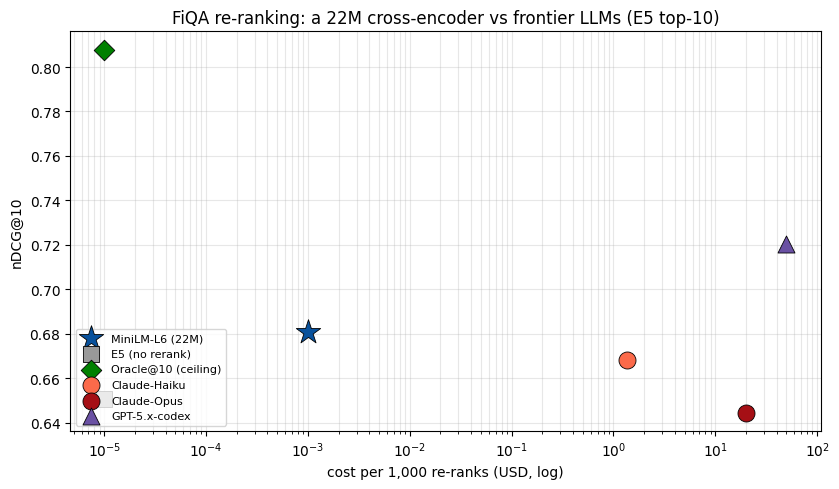

saved phase4_llm_vs_custom.png


In [18]:
fig, ax = plt.subplots(figsize=(8.5,5))
mk = {"MiniLM-L6 (22M)":("#08519c","*",340), "E5 (no rerank)":("#999999","s",120),
      "Oracle@10 (ceiling)":("green","D",110), "Claude-Haiku":("#fb6a4a","o",150),
      "Claude-Opus":("#a50f15","o",150), "GPT-5.x-codex":("#6a51a3","^",150)}
for k,v in results.items():
    col,marker,sz = mk.get(k,("k","o",100))
    ax.scatter(max(v["cost"]*1000,1e-5), v["m"]["ndcg@10"], c=col, marker=marker, s=sz,
               label=k, edgecolors="k", lw=0.6, zorder=3)
ax.set_xscale("log"); ax.set_xlabel("cost per 1,000 re-ranks (USD, log)"); ax.set_ylabel("nDCG@10")
ax.set_title("FiQA re-ranking: a 22M cross-encoder vs frontier LLMs (E5 top-10)")
ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=8, loc="lower left")
plt.tight_layout(); plt.savefig(f"{RES}/phase4_llm_vs_custom.png", dpi=130, bbox_inches="tight"); plt.show()
print("saved phase4_llm_vs_custom.png")

## Exp 4.6 — Error analysis: where re-ranking *breaks* good first-stage ranks
Per-query Δ nDCG@10 (BGE-base − E5) on FiQA. Re-ranking is not free — for some queries the CE over-trusts surface match and demotes a gold passage E5 ranked #1. "Rescued" (Δ>0) vs "broken" (Δ<0) gives the risk profile; the worst breakage is the most instructive failure.

In [19]:
c = CORP["fiqa"]; bge_run = RUNS[("BGE-base","fiqa")]
deltas = []
for qid in c["q_ids"]:
    e = evaluate({qid: c["base_run"][qid]}, {qid: c["qrels"][qid]})["ndcg@10"]
    r = evaluate({qid: bge_run[qid]},       {qid: c["qrels"][qid]})["ndcg@10"]
    deltas.append((qid, r-e, e, r))
dd = pd.DataFrame(deltas, columns=["qid","delta","e5","bge"])
resc = int((dd.delta>1e-6).sum()); brok = int((dd.delta<-1e-6).sum()); same = int((dd.delta.abs()<=1e-6).sum())
print(f"FiQA BGE-base vs E5 over {len(dd)} queries: rescued={resc} broken={brok} unchanged={same}")
print(f"mean Δ={dd.delta.mean():+.4f} | rescued mean={dd[dd.delta>0].delta.mean():+.4f} "
      f"broken mean={dd[dd.delta<0].delta.mean():+.4f}")
worst = dd.sort_values("delta").iloc[0]
print(f"\nworst breakage qid={worst.qid}: E5 {worst.e5:.3f} -> BGE {worst.bge:.3f}\nquery: {c['queries'][worst.qid][:150]}")

FiQA BGE-base vs E5 over 648 queries: rescued=140 broken=267 unchanged=241
mean Δ=-0.0853 | rescued mean=+0.2307 broken mean=-0.3279

worst breakage qid=4827: E5 1.000 -> BGE 0.000
query: Are all financial advisors compensated in the same way?


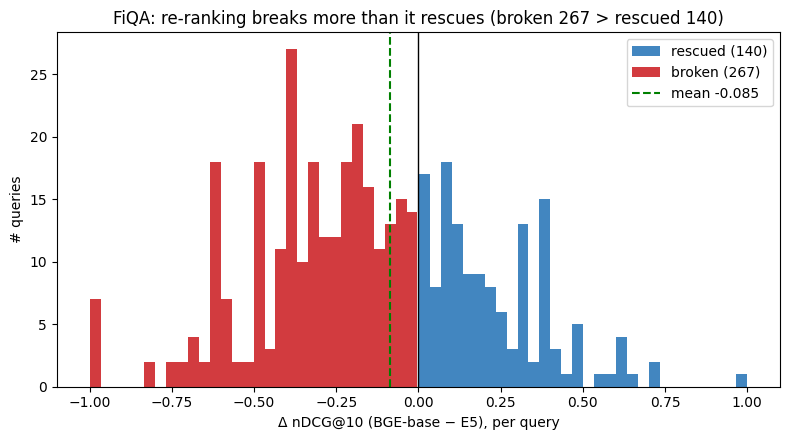

saved phase4_error_analysis.png


In [20]:
fig, ax = plt.subplots(figsize=(8,4.5))
d = dd.delta.values
ax.hist(d[d>1e-6], bins=30, color="#2171b5", alpha=0.85, label=f"rescued ({resc})")
ax.hist(d[d<-1e-6], bins=30, color="#cb181d", alpha=0.85, label=f"broken ({brok})")
ax.axvline(0, c="k", lw=1); ax.axvline(dd.delta.mean(), c="green", ls="--", lw=1.5, label=f"mean {dd.delta.mean():+.3f}")
ax.set_xlabel("Δ nDCG@10 (BGE-base − E5), per query"); ax.set_ylabel("# queries")
ax.set_title("FiQA: re-ranking breaks more than it rescues (broken 267 > rescued 140)")
ax.legend(); plt.tight_layout()
plt.savefig(f"{RES}/phase4_error_analysis.png", dpi=130, bbox_inches="tight"); plt.show()
print("saved phase4_error_analysis.png")

## Phase-4 summary — persist metrics + headline

In [21]:
summary = dict(
    phase=4, date="2026-06-04", task="re-ranking", cand_depth=CAND_DEPTH, rerank_depth=DEPTH,
    e5_baseline={n: CORP[n]["base_m"]["ndcg@10"] for n in CORP},
    oracle_ceiling_100={n: oracle(CORP[n],100) for n in CORP},
    zoo=zoo.to_dict(orient="records"), depth_sweep=sweep.to_dict(orient="records"),
    first_stage=stage.to_dict(orient="records"), llm_vs_custom=h2h.to_dict(orient="records"),
    error_analysis=dict(rescued=resc, broken=brok, unchanged=same, mean_delta=float(dd.delta.mean())))
mpath = f"{RES}/metrics.json"
allm = json.load(open(mpath)) if os.path.exists(mpath) else {}
allm["phase4"] = summary; json.dump(allm, open(mpath,"w"), indent=2)
top = zoo[zoo.dataset=="fiqa"].sort_values("ndcg10", ascending=False).iloc[0]
print("PHASE 4 COMPLETE\n" + "="*60)
print(f"Best FiQA re-ranker: {top['reranker']} nDCG@10={top['ndcg10']:.4f} "
      f"(E5 {CORP['fiqa']['base_m']['ndcg@10']:.4f}, Δ{top['d_ndcg']:+.4f})")
print(f"CE vs LLMs (FiQA n={len(sample_qids)}): CE={results['MiniLM-L6 (22M)']['m']['ndcg@10']:.4f} "
      f"Opus={results['Claude-Opus']['m']['ndcg@10']:.4f} Haiku={results['Claude-Haiku']['m']['ndcg@10']:.4f} "
      f"codex={results['GPT-5.x-codex']['m']['ndcg@10']:.4f}")
print(f"Error profile: rescued {resc} / broke {brok} / unchanged {same}")
print("saved metrics.json[phase4]")

PHASE 4 COMPLETE
Best FiQA re-ranker: MiniLM-L12 nDCG@10=0.3893 (E5 0.3987, Δ-0.0094)
CE vs LLMs (FiQA n=30): CE=0.6807 Opus=0.6443 Haiku=0.6684 codex=0.7203
Error profile: rescued 140 / broke 267 / unchanged 241
saved metrics.json[phase4]
